# Dummy simulation
---

In [1]:
from dual_spls.simulate import simulate
import numpy as np

In [2]:
## Configuration:
# Simulation configuration:
coefs = [0, 1, 0, 1, 1, 0, 0, 1, 1] 
n = 300
p = [1000]
nondes = [30]
sigmaondes = [0.40]
sigma_y = 0.05

# Split configuration:
split_mode = "random"

# Dual-sPLS configuration
norm = "pseudo-lasso" # options: "pseudo-lasso", ...

In [3]:
# generate synthetic data
simulation_results = simulate(n=n, p=p, nondes=nondes , sigmaondes=sigmaondes, sigma_y=sigma_y, coefs=coefs)
X, y = simulation_results["X"], simulation_results["y"]

In [4]:
# split data
if split_mode == "random":
    # split data randomly
    from sklearn.model_selection import train_test_split

    print("Splitting data using a classic random split.")
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Splitting data using a classic random split.


In [5]:
X

array([[ 5.31384882,  5.32655596,  5.33926903, ...,  6.64689331,
         6.63417072,  6.62144308],
       [ 6.60505496,  6.61906001,  6.63306765, ...,  7.93451151,
         7.91971617,  7.9049119 ],
       [ 5.97398644,  5.98682971,  5.99967748, ...,  7.68863987,
         7.67492255,  7.66119471],
       ...,
       [ 6.10525093,  6.11951193,  6.13377992, ...,  8.01873075,
         8.00405786,  7.98937581],
       [ 7.33880927,  7.35595278,  7.37310582, ..., 10.10528933,
        10.0871744 , 10.06904506],
       [ 7.0447016 ,  7.05961125,  7.07452476, ...,  9.36245377,
         9.34688347,  9.33129702]], shape=(300, 1000))

In [6]:
y

array([4810.74158375, 5671.30753756, 5318.59880413, 5039.82208004,
       5454.50365343, 6502.33472336, 6125.36374349, 6636.01498986,
       5132.92089755, 6110.46919445, 5006.15765496, 6988.05350218,
       5655.39867788, 6381.61856885, 7428.88594733, 5956.11429075,
       6677.53023122, 6669.089352  , 5222.01410456, 6034.61553168,
       5228.2470057 , 4859.68746502, 5729.69031508, 5804.52601302,
       5188.56746599, 5857.91465127, 4734.90096409, 5664.72066877,
       5788.43902667, 5237.69548581, 5563.7481477 , 5096.36094411,
       6372.63674494, 5820.79977904, 6082.05424748, 6947.50121969,
       5984.96755324, 4858.02494088, 6793.70123061, 5797.98432675,
       6409.53951174, 5806.70399613, 5914.4023097 , 6130.0249503 ,
       5669.73874159, 7158.5293414 , 5728.50744747, 5254.13940923,
       6388.220829  , 6043.93392349, 4973.97138154, 5811.5539907 ,
       6211.25968506, 5669.58100753, 5265.0181107 , 4844.56244916,
       5146.01094168, 5805.54673456, 6042.2087835 , 5418.96196

In [7]:
# standardize data (after splitting to avoid data leakage)
from sklearn.preprocessing import StandardScaler

X_scaler = StandardScaler()
X_train_scaled = X_scaler.fit_transform(X_train)
X_test_scaled = X_scaler.transform(X_test)       

y_scaler = StandardScaler()
y_train_scaled= y_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1)).flatten()


In [8]:
# apply Dual-sPLS
from dual_spls.lasso import dual_spls_lasso

results = {}
if norm == "pseudo-lasso":
    print("Applying Dual-sPLS with the \"pseudo-lasso\" norm.")

    for n_comp in range(1, 10):
        result = dual_spls_lasso(X_train_scaled, y_train_scaled, n_components=n_comp, ppnu=0.99)
        beta = result['Bhat'][:, -1]
        intercept = result['intercept'][-1]

        y_pred_scaled = (X_test_scaled @ beta + intercept).flatten()

        rmse = np.sqrt(np.mean((y_test_scaled - y_pred_scaled)**2))
        results[f"rmse_{n_comp}_comp"] = rmse

results

Applying Dual-sPLS with the "pseudo-lasso" norm.


{'rmse_1_comp': np.float64(0.07775115330926535),
 'rmse_2_comp': np.float64(0.06917143644698226),
 'rmse_3_comp': np.float64(0.00712691669372045),
 'rmse_4_comp': np.float64(0.0008731545993763213),
 'rmse_5_comp': np.float64(7.976860700892308e-05),
 'rmse_6_comp': np.float64(7.488757024247058e-05),
 'rmse_7_comp': np.float64(7.640979485084724e-05),
 'rmse_8_comp': np.float64(7.64130805889237e-05),
 'rmse_9_comp': np.float64(7.699486395986161e-05)}

In [9]:
# apply PLS
from sklearn.cross_decomposition import PLSRegression

results_PLS = {}
for n_comp in range(1, 10):
        PLS = PLSRegression(n_components=n_comp, scale=False, copy=True)
        PLS.fit(X_train_scaled, y_train_scaled)

        y_pred_scaled = PLS.predict(X_test_scaled).flatten()

        rmse = np.sqrt(np.mean((y_test_scaled - y_pred_scaled)**2))
        results_PLS[f"rmse_{n_comp}_comp"] = rmse

results_PLS

{'rmse_1_comp': np.float64(0.060960112552175635),
 'rmse_2_comp': np.float64(0.00506746065496374),
 'rmse_3_comp': np.float64(0.0036155884857353524),
 'rmse_4_comp': np.float64(0.00011458479299869198),
 'rmse_5_comp': np.float64(7.487484926885469e-05),
 'rmse_6_comp': np.float64(7.609065840460126e-05),
 'rmse_7_comp': np.float64(7.63867182116253e-05),
 'rmse_8_comp': np.float64(7.640157436984692e-05),
 'rmse_9_comp': np.float64(7.698739905894702e-05)}

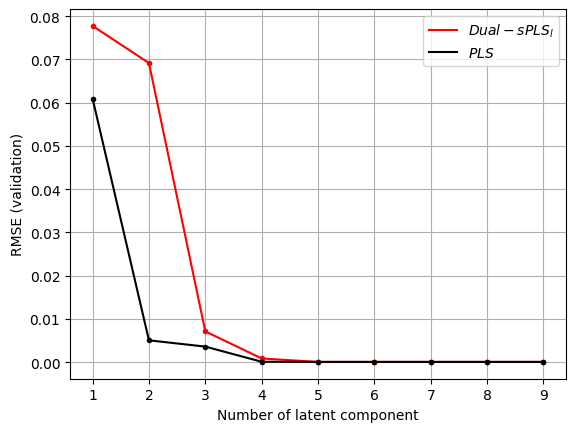

In [10]:
import matplotlib.pyplot as plt

plt.plot(range(1, 10), list(results.values()), color='red',label="$Dual-sPLS_l$")
plt.plot(range(1, 10), list(results.values()), ".", color='red')

plt.plot(range(1, 10), list(results_PLS.values()), color='black',label="$PLS$")
plt.plot(range(1, 10), list(results_PLS.values()), ".", color='black')

plt.xlabel("Number of latent component")
plt.ylabel("RMSE (validation)")
plt.grid()
plt.legend()
plt.show()